## NASA: Asteroids Classification

In [57]:
!pip install xgboost

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!wget https://raw.githubusercontent.com/guymorag1/Asteroid-Classifier/main/nasa.csv
nasa = pd.read_csv('nasa.csv')
nasa.head()

--2026-06-08 05:48:01--  https://raw.githubusercontent.com/guymorag1/Asteroid-Classifier/main/nasa.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2425254 (2.3M) [text/plain]
Saving to: ‘nasa.csv.4’

nasa.csv.4          100%[===================>]   2.31M  12.6MB/s    in 0.2s    

2026-06-08 05:48:01 (12.6 MB/s) - ‘nasa.csv.4’ saved [2425254/2425254]



,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [59]:
nasa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Close Approach Date           4687 non-null   object 
 12  Epoch Date Close Approach     4687 non-null   int64  
 13  Rel

In [60]:
nasa.duplicated().sum() # no duplicate

np.int64(0)

In [61]:
nasa.isna().sum() # no na value

,0
Neo Reference ID,0
Name,0
Absolute Magnitude,0
Est Dia in KM(min),0
Est Dia in KM(max),0
Est Dia in M(min),0
Est Dia in M(max),0
Est Dia in Miles(min),0
Est Dia in Miles(max),0
Est Dia in Feet(min),0


In [62]:
y = nasa["Hazardous"]
y_encoded = y.astype(int) #target variable

X = nasa.drop([
    "Name",
    "Neo Reference ID",
    "Orbit ID",
    "Close Approach Date",
    "Orbit Determination Date",
    "Equinox",
    "Orbiting Body",

    # duplicated diameter units
    "Est Dia in M(min)",
    "Est Dia in M(max)",
    "Est Dia in Miles(min)",
    "Est Dia in Miles(max)",
    "Est Dia in Feet(min)",
    "Est Dia in Feet(max)",

    # duplicated distance units
    "Miss Dist.(lunar)",
    "Miss Dist.(kilometers)",
    "Miss Dist.(miles)",

    # duplicated velocity units
    "Miles per hour",
    "Relative Velocity km per hr",

    "Minimum Orbit Intersection", # the hazardous label  is largely determined by this col
    "Absolute Magnitude", # the hazardous label  is largely determined by this col

    "Hazardous" #target
], axis=1)

X.head(5)

,Est Dia in KM(min),Est Dia in KM(max),Epoch Date Close Approach,Relative Velocity km per sec,Miss Dist.(Astronomical),Orbit Uncertainity,Jupiter Tisserand Invariant,Epoch Osculation,Eccentricity,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
0,0.127220,0.284472,788947200000,6.115834,0.419483,5,4.634,2458000.5,0.425549,1.407011,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551
1,0.146068,0.326618,788947200000,18.113985,0.383014,3,5.457,2458000.5,0.351674,1.107776,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330
2,0.231502,0.517654,789552000000,7.590711,0.050956,0,4.557,2458000.5,0.348248,1.458824,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371
3,0.008801,0.019681,790156800000,11.173874,0.285322,6,5.093,2458000.5,0.216578,1.255903,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277
4,0.127220,0.284472,790156800000,9.840831,0.407832,1,5.154,2458000.5,0.210448,1.225615,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395


In [63]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Est Dia in KM(min)            4687 non-null   float64
 1   Est Dia in KM(max)            4687 non-null   float64
 2   Epoch Date Close Approach     4687 non-null   int64  
 3   Relative Velocity km per sec  4687 non-null   float64
 4   Miss Dist.(Astronomical)      4687 non-null   float64
 5   Orbit Uncertainity            4687 non-null   int64  
 6   Jupiter Tisserand Invariant   4687 non-null   float64
 7   Epoch Osculation              4687 non-null   float64
 8   Eccentricity                  4687 non-null   float64
 9   Semi Major Axis               4687 non-null   float64
 10  Inclination                   4687 non-null   float64
 11  Asc Node Longitude            4687 non-null   float64
 12  Orbital Period                4687 non-null   float64
 13  Per

In [64]:
y_encoded.value_counts()

,count
Hazardous,
0,3932
1,755


In [65]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

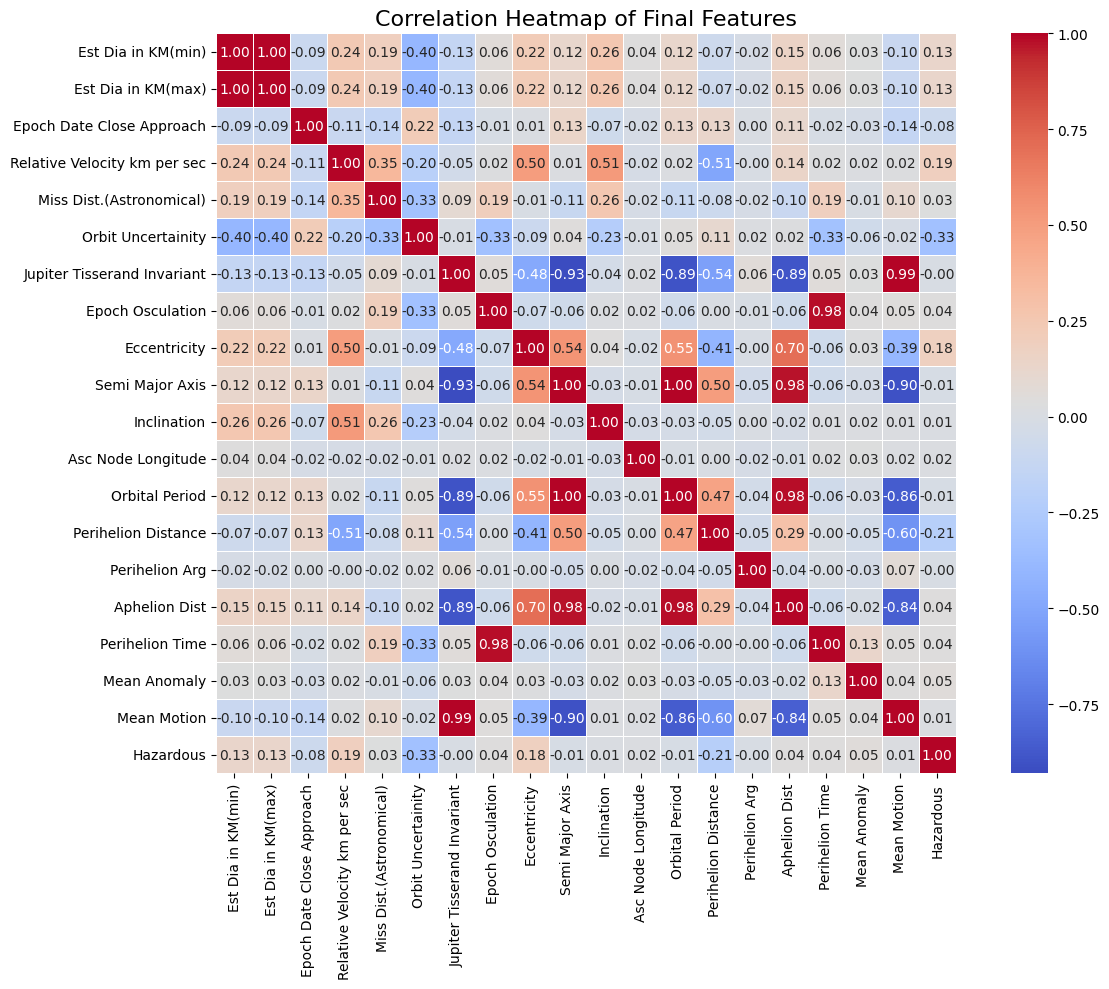

In [66]:
# correlation heatmap

heatmap_df = X.copy()
heatmap_df["Hazardous"] = y_encoded

corr_matrix = heatmap_df.corr()

plt.figure(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Final Features", fontsize=16)
plt.tight_layout()
plt.show()

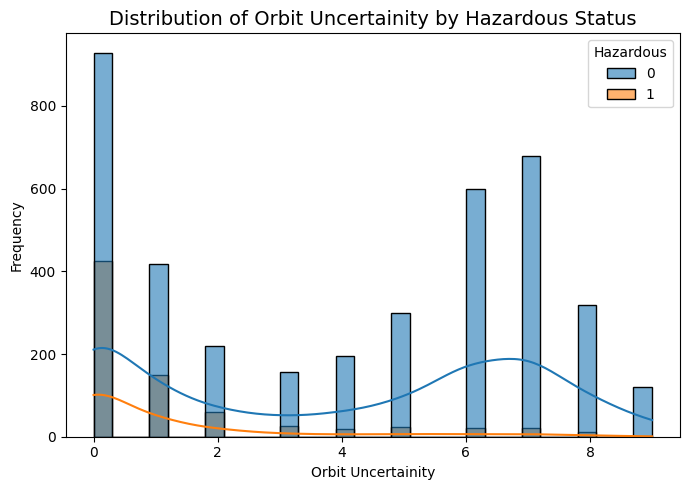

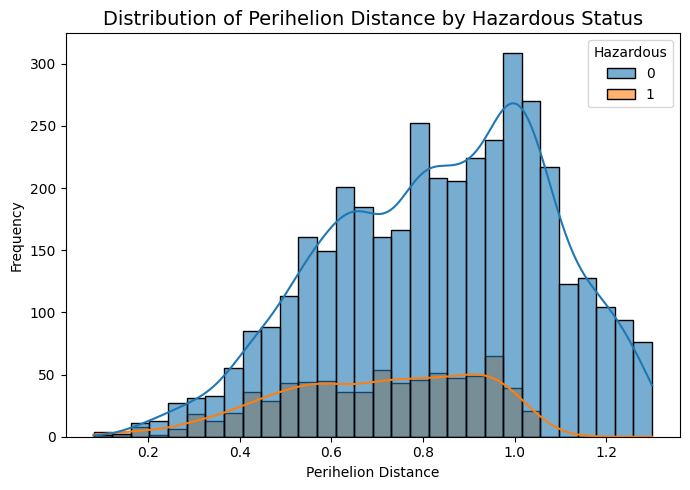

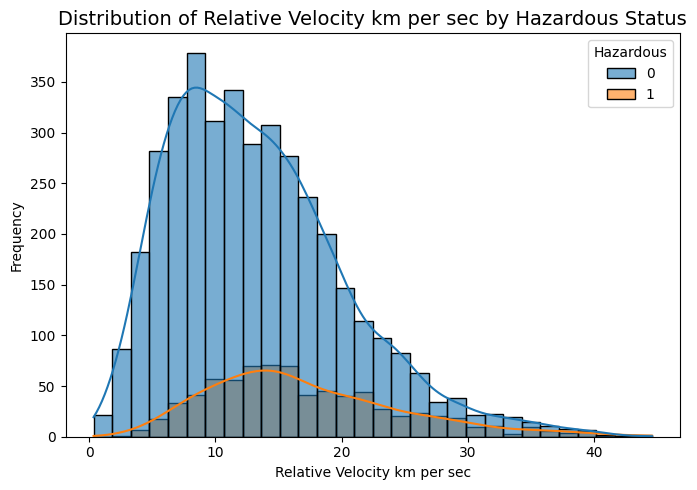

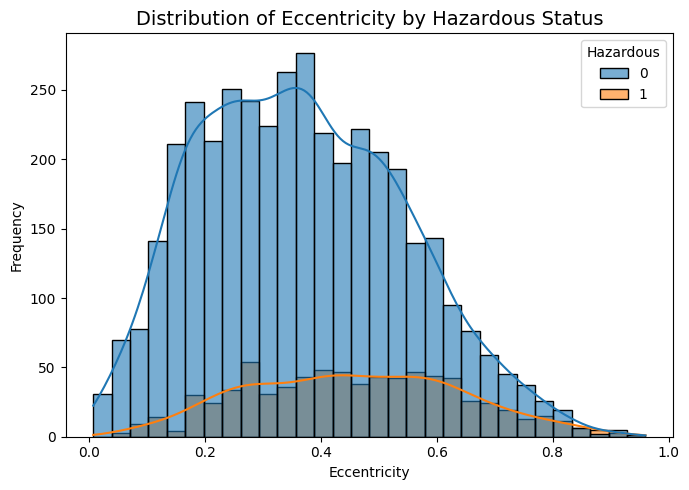

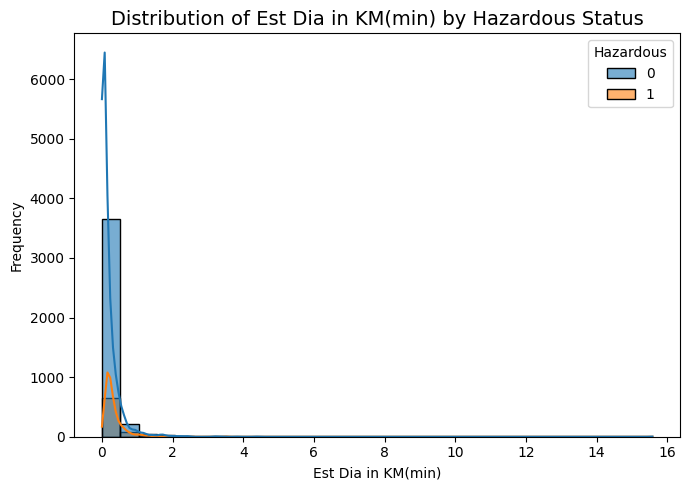

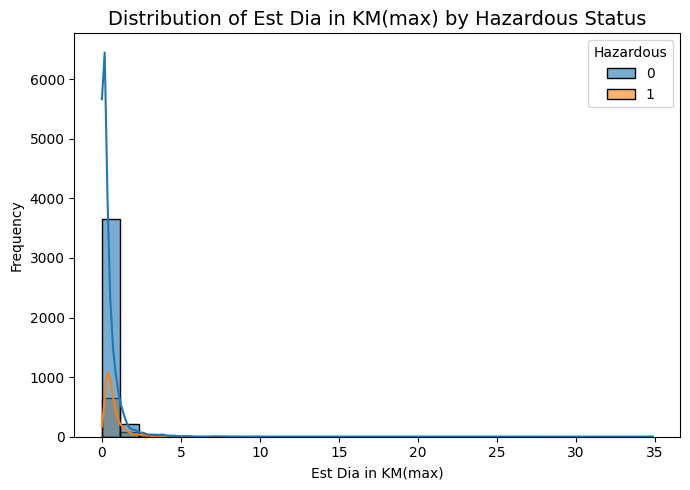

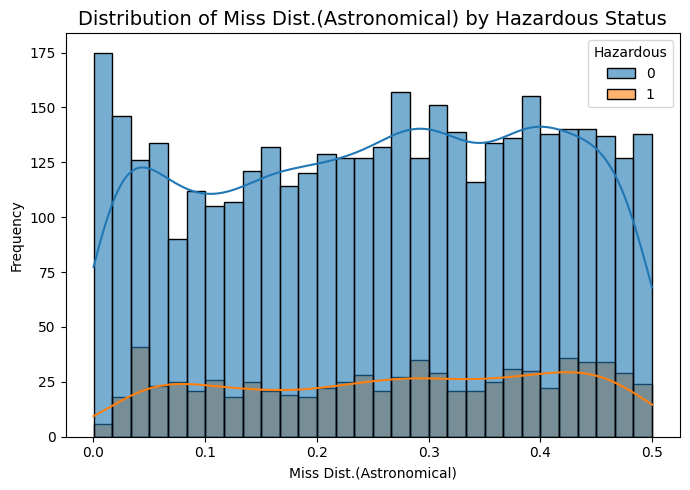

In [67]:
# distribution of important features by hazardous status

eda_df = X.copy()
eda_df["Hazardous"] = y_encoded

features_to_plot = [
    "Orbit Uncertainity",
    "Perihelion Distance",
    "Relative Velocity km per sec",
    "Eccentricity",
    "Est Dia in KM(min)",
    "Est Dia in KM(max)",
    "Miss Dist.(Astronomical)"
]

for feature in features_to_plot:
    plt.figure(figsize=(7, 5))

    sns.histplot(
        data=eda_df,
        x=feature,
        hue="Hazardous",
        kde=True,
        bins=30,
        alpha=0.6
    )

    plt.title(f"Distribution of {feature} by Hazardous Status", fontsize=14)
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size = 0.2,
    random_state= 42,
    stratify= y_encoded
)

## Logistic Regression

In [69]:
# Logistic Regression without Standardization

lr = LogisticRegression(class_weight ='balanced', max_iter = 1000, random_state = 42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8390191897654584
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Confusion Matrix:
[[787   0]
 [151   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       787
           1       0.00      0.00      0.00       151

    accuracy                           0.84       938
   macro avg       0.42      0.50      0.46       938
weighted avg       0.70      0.84      0.77       938



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [70]:
# Logistic Regression with standardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7078891257995735
Precision: 0.3315068493150685
Recall: 0.8013245033112583
F1 Score: 0.4689922480620155
Confusion Matrix:
[[543 244]
 [ 30 121]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.69      0.80       787
           1       0.33      0.80      0.47       151

    accuracy                           0.71       938
   macro avg       0.64      0.75      0.63       938
weighted avg       0.85      0.71      0.75       938



## Random Forest

In [71]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 2,
    class_weight = "balanced",
    random_state = 42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8560767590618337
Precision: 0.5296296296296297
Recall: 0.9470198675496688
F1 Score: 0.6793349168646081
Confusion Matrix:
[[660 127]
 [  8 143]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91       787
           1       0.53      0.95      0.68       151

    accuracy                           0.86       938
   macro avg       0.76      0.89      0.79       938
weighted avg       0.91      0.86      0.87       938



In [72]:
# rf_params = {
#    "n_estimators": [100, 200, 300, 500],
#    "max_depth": [5, 10, 20, 30],
#    "min_samples_split": [2, 5, 10],
#    "min_samples_leaf": [1, 2, 3, 4]
# }

# rf_grid = GridSearchCV(
#    estimator = RandomForestClassifier(
#       class_weight = "balanced",
#       random_state = 42
#    ),
#    param_grid = rf_params,
#    cv = 5,
#    scoring = "f1",
#    verbose = 1,
#    n_jobs = -1
# )

# rf_grid.fit(X_train, y_train)

# print("Best Parameters:", rf_grid.best_params_)
# print("Best Score:", rf_grid.best_score_)

best_rf = RandomForestClassifier(
    max_depth=30,
    min_samples_leaf=3,
    min_samples_split=2,
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
best_rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=30,
                       min_samples_leaf=3, n_estimators=200, random_state=42)

In [73]:
# best_rf = rf_grid.best_estimator_

y_pred = best_rf.predict(X_test)

print("Tuned Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Tuned Random Forest
Accuracy: 0.9307036247334755
Precision: 0.7945205479452054
Recall: 0.7682119205298014
F1 Score: 0.7811447811447811
[[757  30]
 [ 35 116]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       787
           1       0.79      0.77      0.78       151

    accuracy                           0.93       938
   macro avg       0.88      0.87      0.87       938
weighted avg       0.93      0.93      0.93       938



## XGBoost

In [74]:
# XGBoost

scale_pos_weight = 3932 / 755 #adjust for class imbalance

xgb_model = XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 4,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    eval_metric = "logloss",
    random_state = 42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8891257995735607
Precision: 0.6053811659192825
Recall: 0.8940397350993378
F1 Score: 0.7219251336898396
Confusion Matrix:
[[699  88]
 [ 16 135]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       787
           1       0.61      0.89      0.72       151

    accuracy                           0.89       938
   macro avg       0.79      0.89      0.83       938
weighted avg       0.92      0.89      0.90       938



In [75]:
# xgb_params = {
#    "n_estimators": [100, 200, 300, 500],
#    "learning_rate": [0.01, 0.05, 0.1, 0.2],
#    "max_depth": [3, 4, 5, 6],
#    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
#}

# xgb_grid = GridSearchCV(
#    estimator = XGBClassifier(
#       scale_pos_weight = scale_pos_weight,
#        eval_metric = "logloss",
#        random_state = 42
#    ),
#    param_grid = xgb_params,
#    cv = 5,
#    scoring = "f1",
#    verbose = 1,
#    n_jobs = -1
#)
#
# xgb_grid.fit(X_train, y_train)


#print("Best Parameters:", xgb_grid.best_params_)
#print("Best Score:", xgb_grid.best_score_)

best_xgb = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.2,
    max_depth=6,
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [76]:
# best_xgb = xgb_grid.best_estimator_

y_pred = best_xgb.predict(X_test)

print("Tuned XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Tuned XGBoost
Accuracy: 0.9477611940298507
Precision: 0.81875
Recall: 0.8675496688741722
F1 Score: 0.842443729903537
[[758  29]
 [ 20 131]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       787
           1       0.82      0.87      0.84       151

    accuracy                           0.95       938
   macro avg       0.90      0.92      0.91       938
weighted avg       0.95      0.95      0.95       938



In [77]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(15))

                         feature  importance
1             Est Dia in KM(max)    0.235569
0             Est Dia in KM(min)    0.209521
13           Perihelion Distance    0.105432
10                   Inclination    0.057605
5             Orbit Uncertainity    0.043240
14                Perihelion Arg    0.041113
12                Orbital Period    0.040752
4       Miss Dist.(Astronomical)    0.038501
15                 Aphelion Dist    0.029168
9                Semi Major Axis    0.026332
8                   Eccentricity    0.024339
3   Relative Velocity km per sec    0.023918
18                   Mean Motion    0.023867
6    Jupiter Tisserand Invariant    0.020753
11            Asc Node Longitude    0.020271


In [78]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(15))

                        feature  importance
0            Est Dia in KM(min)    0.347251
13          Perihelion Distance    0.148855
10                  Inclination    0.060614
14               Perihelion Arg    0.059166
7              Epoch Osculation    0.054016
15                Aphelion Dist    0.040214
5            Orbit Uncertainity    0.035706
4      Miss Dist.(Astronomical)    0.034029
9               Semi Major Axis    0.027942
6   Jupiter Tisserand Invariant    0.027910
18                  Mean Motion    0.026272
16              Perihelion Time    0.025695
17                 Mean Anomaly    0.024226
8                  Eccentricity    0.024029
11           Asc Node Longitude    0.023455


## Check for data leakage

In [79]:
y1 = nasa["Hazardous"]
y1_encoded = y1.astype(int) #target variable

X1 = nasa.drop([
    "Name",
    "Neo Reference ID",
    "Orbit ID",
    "Close Approach Date",
    "Orbit Determination Date",
    "Equinox",
    "Orbiting Body",

    # duplicated diameter units
    "Est Dia in M(min)",
    "Est Dia in M(max)",
    "Est Dia in Miles(min)",
    "Est Dia in Miles(max)",
    "Est Dia in Feet(min)",
    "Est Dia in Feet(max)",

    # duplicated distance units
    "Miss Dist.(lunar)",
    "Miss Dist.(kilometers)",
    "Miss Dist.(miles)",

    # duplicated velocity units
    "Miles per hour",
    "Relative Velocity km per hr",

    #"Minimum Orbit Intersection", # the hazardous label  is largely determined by this col
    "Absolute Magnitude", # the hazardous label  is largely determined by this col

    "Hazardous" #target
], axis=1)

X1.head(5)

,Est Dia in KM(min),Est Dia in KM(max),Epoch Date Close Approach,Relative Velocity km per sec,Miss Dist.(Astronomical),Orbit Uncertainity,Minimum Orbit Intersection,Jupiter Tisserand Invariant,Epoch Osculation,Eccentricity,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
0,0.127220,0.284472,788947200000,6.115834,0.419483,5,0.025282,4.634,2458000.5,0.425549,1.407011,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551
1,0.146068,0.326618,788947200000,18.113985,0.383014,3,0.186935,5.457,2458000.5,0.351674,1.107776,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330
2,0.231502,0.517654,789552000000,7.590711,0.050956,0,0.043058,4.557,2458000.5,0.348248,1.458824,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371
3,0.008801,0.019681,790156800000,11.173874,0.285322,6,0.005512,5.093,2458000.5,0.216578,1.255903,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277
4,0.127220,0.284472,790156800000,9.840831,0.407832,1,0.034798,5.154,2458000.5,0.210448,1.225615,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395


In [80]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1,
    y1_encoded,
    test_size=0.2,
    random_state= 42,
    stratify=y1_encoded
)

In [81]:
xgb_model1 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight= 3932 / 755,
    eval_metric="logloss",
    random_state=42
)

xgb_model1.fit(X_train1, y_train1)

y_pred1 = xgb_model1.predict(X_test1)
y_pred_proba1 = xgb_model1.predict_proba(X_test1)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test1, y_pred1))

print("\nClassification Report:")
print(classification_report(y_test1, y_pred1))

print("Accuracy:", accuracy_score(y_test1, y_pred1))
print("ROC-AUC:", roc_auc_score(y_test1, y_pred_proba1))

Confusion Matrix:
[[786   1]
 [  1 150]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       0.99      0.99      0.99       151

    accuracy                           1.00       938
   macro avg       1.00      1.00      1.00       938
weighted avg       1.00      1.00      1.00       938

Accuracy: 0.997867803837953
ROC-AUC: 0.9999747553371424


In [82]:
y = nasa["Hazardous"]
y_encoded = y.astype(int) #target variable

X = nasa.drop([
    "Name",
    "Neo Reference ID",
    "Orbit ID",
    "Close Approach Date",
    "Orbit Determination Date",
    "Equinox",
    "Orbiting Body",

    # duplicated diameter units
    "Est Dia in M(min)",
    "Est Dia in M(max)",
    "Est Dia in Miles(min)",
    "Est Dia in Miles(max)",
    "Est Dia in Feet(min)",
    "Est Dia in Feet(max)",

    # duplicated distance units
    "Miss Dist.(lunar)",
    "Miss Dist.(kilometers)",
    "Miss Dist.(miles)",

    # duplicated velocity units
    "Miles per hour",
    "Relative Velocity km per hr",

    "Minimum Orbit Intersection", # the hazardous label  is largely determined by this col
    #"Absolute Magnitude", # the hazardous label  is largely determined by this col

    "Hazardous" #target
], axis=1)

In [83]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1,
    y1_encoded,
    test_size=0.2,
    random_state= 42,
    stratify=y1_encoded
)

In [84]:
xgb_model1 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight= 3932 / 755,
    eval_metric="logloss",
    random_state=42
)

xgb_model1.fit(X_train1, y_train1)

y_pred1 = xgb_model1.predict(X_test1)
y_pred_proba1 = xgb_model1.predict_proba(X_test1)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test1, y_pred1))

print("\nClassification Report:")
print(classification_report(y_test1, y_pred1))

print("Accuracy:", accuracy_score(y_test1, y_pred1))
print("ROC-AUC:", roc_auc_score(y_test1, y_pred_proba1))

Confusion Matrix:
[[786   1]
 [  1 150]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       787
           1       0.99      0.99      0.99       151

    accuracy                           1.00       938
   macro avg       1.00      1.00      1.00       938
weighted avg       1.00      1.00      1.00       938

Accuracy: 0.997867803837953
ROC-AUC: 0.9999747553371424
